# Task C/D — SimCLR Downstream (Decoder Attachment + Fine-tuning)
### CSE 438 Part B — SSL for Semantic Segmentation

This notebook continues from `task_b_simclr.ipynb`'s saved encoder checkpoint.

**Task C (this section):** attach the ASPP decoder — reused directly from
your Part A DeepLabV3 notebook (`model.classifier`), not reimplemented —
onto the SimCLR encoder's `[2048, H, W]` feature map. No channel adapter is
needed here since SimCLR's ResNet-50 backbone already outputs 2048 channels,
matching what the borrowed ASPP head expects.

**Resolution note:** using 224x224 (matches Task B encoders as-is). Part A's
`deeplabv3_resnet50` uses dilated convolutions internally (output stride 8);
this plain ResNet-50 encoder uses standard stride 32, so the feature map here
(7x7 at 224 input) is coarser than Part A's (28x28 at the same input size
under stride 8). State this explicitly in Section 6.4 of the report — it's a
real, deliberate simplification, not an oversight.

In [33]:
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## Config

In [34]:
CONFIG = {
    "method": "SimCLR",
    "num_classes": 24,          # matches Part A's Semantic Drone Dataset class count
    "image_size": 224,
    "encoder_out_channels": 2048,
    "freeze_encoder": True,     # toggle this for the frozen-vs-fine-tuned comparison (Task C requirement)
    "encoder_checkpoint": "/kaggle/input/notebooks/mashrur135/simclr-ep1/simclr_encoder_checkpoint.pth",
}
print(json.dumps(CONFIG, indent=2))


{
  "method": "SimCLR",
  "num_classes": 24,
  "image_size": 224,
  "encoder_out_channels": 2048,
  "freeze_encoder": true,
  "encoder_checkpoint": "/kaggle/input/notebooks/mashrur135/simclr-ep1/simclr_encoder_checkpoint.pth"
}


## Re-declare the SimCLR encoder class

Kaggle notebooks are isolated — this class must be redefined here (identical
to the one in `task_b_simclr.ipynb`) so the saved `backbone_state_dict` can
be loaded into a matching architecture.

In [35]:
class SimCLREncoder(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V2" if pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # -> [B, 2048, H, W]

    def forward(self, x):
        return self.backbone(x)


encoder = SimCLREncoder(pretrained=False).to(DEVICE)

checkpoint = torch.load(CONFIG["encoder_checkpoint"], map_location=DEVICE)
encoder.backbone.load_state_dict(checkpoint["backbone_state_dict"])
print(f"Loaded SimCLR encoder, pretrained for {checkpoint['config']['pretrain_epochs']} epochs,")
print(f"final NT-Xent loss: {checkpoint['final_loss']:.4f}")


Loaded SimCLR encoder, pretrained for 1 epochs,
final NT-Xent loss: 3.5390


## Decoder — reused directly from Part A's DeepLabV3

`model.classifier` from torchvision's `deeplabv3_resnet50` IS the ASPP head
your group already trained-with in Part A. We take the full model just to
extract this exact module, then discard the rest (its own ResNet-50 backbone
isn't needed here — the SSL encoder replaces it).

In [36]:
_deeplab_full = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
_deeplab_full.classifier[4] = nn.Conv2d(256, CONFIG["num_classes"], kernel_size=1)  # matches Part A exactly

decoder = _deeplab_full.classifier   # this is the ASPP head + final classifier conv
del _deeplab_full                     # its own backbone is not needed

decoder = decoder.to(DEVICE)
print(decoder)


DeepLabHead(
  (0): ASPP(
    (convs): ModuleList(
      (0): Sequential(
        (0): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (1): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(12, 12), dilation=(12, 12), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(24, 24), dilation=(24, 24), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(36, 36), dilation=(36, 36), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

## Combined segmentation model

`freeze_encoder=True` -> only decoder parameters get gradients (linear
probing). `freeze_encoder=False` -> both encoder and decoder train (full
fine-tuning). This flag is exactly what Task C asks you to compare for at
least one method — try both here and record the difference before choosing
one strategy for the rest.

In [37]:
class SegmentationModel(nn.Module):
    def __init__(self, encoder, decoder, image_size, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.image_size = image_size
        self.set_encoder_frozen(freeze_encoder)

    def set_encoder_frozen(self, freeze):
        for p in self.encoder.parameters():
            p.requires_grad = not freeze
        self.encoder.train(not freeze)   # keep BatchNorm in eval mode when frozen

    def forward(self, x):
        if not any(p.requires_grad for p in self.encoder.parameters()):
            with torch.no_grad():
                features = self.encoder(x)          # [B, 2048, H, W]
        else:
            features = self.encoder(x)
        logits = self.decoder(features)              # [B, num_classes, H, W] (still coarse)
        logits = F.interpolate(logits, size=(self.image_size, self.image_size),
                                mode="bilinear", align_corners=False)
        return logits


model = SegmentationModel(encoder, decoder, CONFIG["image_size"],
                           freeze_encoder=CONFIG["freeze_encoder"]).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({'frozen encoder' if CONFIG['freeze_encoder'] else 'fine-tuned encoder'})")


Trainable params: 16,131,608 / 39,639,640 (frozen encoder)


## Shape check with a dummy tensor (do this before touching real data)

In [38]:
with torch.no_grad():
    dummy = torch.randn(2, 3, CONFIG["image_size"], CONFIG["image_size"]).to(DEVICE)
    out = model(dummy)
    print(f"Input:  {dummy.shape}")
    print(f"Output: {out.shape}")   # expect [2, num_classes, 224, 224]
    assert out.shape == (2, CONFIG["num_classes"], CONFIG["image_size"], CONFIG["image_size"])
    print("Shape check passed ✅ -- ready for Task D (fine-tuning on the validation split).")


Input:  torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 24, 224, 224])
Shape check passed ✅ -- ready for Task D (fine-tuning on the validation split).


---
# Task D — Supervised Fine-tuning

Fine-tune on the **validation split** (the small labelled fine-tuning set,
per Section 2's role mapping), monitor **mIoU on the test split** each epoch
(the test split's double role: monitoring here, final Task E metrics later),
save the best checkpoint by that signal, for exactly 50 epochs (fixed
requirement — report the final mIoU at epoch 50 even if still improving).

In [39]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

DATA_PREP_DIR = "/kaggle/input/notebooks/mashrur135/nb-01/artifacts/splits"

valid_df = pd.read_csv(f"{DATA_PREP_DIR}/valid_split.csv")
test_df  = pd.read_csv(f"{DATA_PREP_DIR}/test_split.csv")

print(f"Validation (labelled fine-tuning set): {len(valid_df)} images")
print(f"Test (monitoring + final eval):        {len(test_df)} images")


Validation (labelled fine-tuning set): 60 images
Test (monitoring + final eval):        60 images


## Fine-tuning config (add to the existing CONFIG dict from Task C)

In [40]:
FT_CONFIG = {
    "finetune_epochs": 5,
    "batch_size": 8,
    "encoder_lr": 1e-5,     # small LR for the pretrained encoder (only used if NOT frozen)
    "decoder_lr": 1e-4,     # larger LR for the decoder + adapter (always trained from scratch here)
    "optimizer": "AdamW",
    "weight_decay": 1e-4,
    "scheduler": "ReduceLROnPlateau",
}
print(json.dumps(FT_CONFIG, indent=2))


{
  "finetune_epochs": 5,
  "batch_size": 8,
  "encoder_lr": 1e-05,
  "decoder_lr": 0.0001,
  "optimizer": "AdamW",
  "weight_decay": 0.0001,
  "scheduler": "ReduceLROnPlateau"
}


## Fine-tuning transforms + Dataset

Validation gets light augmentation (labelled fine-tuning data); test stays
fully deterministic, matching the data-prep notebook's contracts exactly.

In [41]:
def read_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return mask

finetune_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.Normalize(),
    ToTensorV2(),
])


class SegDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        mask = read_mask(row["mask_path"])
        out = self.transform(image=image, mask=mask)
        return out["image"], out["mask"].long()


valid_dataset = SegDataset(valid_df, finetune_transform)
test_dataset  = SegDataset(test_df, eval_transform)

valid_loader = DataLoader(valid_dataset, batch_size=FT_CONFIG["batch_size"], shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=FT_CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches:       {len(test_loader)}")


Validation batches: 8
Test batches:       8


## Class weights from the validation split's pixel distribution

Mirrors Part A's approach exactly, but computed from the VALIDATION split
here (since that's the labelled fine-tuning data in Part B), not train.

In [42]:
pixel_counts = Counter()
for mask_path in valid_df["mask_path"]:
    mask = read_mask(mask_path)
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        pixel_counts[int(u)] += int(c)

class_pixel_counts = np.array([pixel_counts.get(c, 0) for c in range(CONFIG["num_classes"])], dtype=np.float64)
epsilon = 1.0
inverse_freq = 1.0 / (class_pixel_counts + epsilon)
class_weights = inverse_freq / inverse_freq.mean()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights computed from validation-split pixel distribution.")


Class weights computed from validation-split pixel distribution.


## Metric functions (identical to Part A — same implementation, for a fair comparison)

In [43]:
def per_class_iou(preds, masks, num_classes):
    preds = preds.reshape(-1); masks = masks.reshape(-1)
    ious = []
    for cls in range(num_classes):
        pred_cls, mask_cls = preds == cls, masks == cls
        intersection = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()
        ious.append(float("nan") if union == 0 else intersection / union)
    return ious

def mean_iou(preds, masks, num_classes):
    return float(np.nanmean(per_class_iou(preds, masks, num_classes)))

def pixel_accuracy(preds, masks):
    return (preds == masks).sum().item() / masks.numel()

def dice_score(preds, masks, num_classes):
    scores = []
    for cls in range(num_classes):
        pred_cls, gt_cls = preds == cls, masks == cls
        intersection = (pred_cls & gt_cls).sum().item()
        denom = pred_cls.sum().item() + gt_cls.sum().item()
        if denom == 0: continue
        scores.append((2 * intersection) / denom)
    return float(np.mean(scores))


## Optimizer — separate LR for encoder vs decoder (only matters when NOT frozen)

In [44]:
param_groups = [{"params": model.decoder.parameters(), "lr": FT_CONFIG["decoder_lr"]}]
if hasattr(model, "adapter"):
    param_groups.append({"params": model.adapter.parameters(), "lr": FT_CONFIG["decoder_lr"]})
if not CONFIG["freeze_encoder"]:
    param_groups.append({"params": model.encoder.parameters(), "lr": FT_CONFIG["encoder_lr"]})

optimizer = torch.optim.AdamW(param_groups, weight_decay=FT_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Optimizer set up with {len(param_groups)} param group(s).")


Optimizer set up with 1 param group(s).


## Training loop (50 epochs, fixed requirement)

Trains on validation-split labelled data; monitors mIoU on the test split
each epoch (per Section 2's caveat: test split doubles as downstream
validation here). Saves the best checkpoint by test-split mIoU.

In [45]:
train_losses, valid_losses_monitor, monitor_mious = [], [], []
best_miou = 0.0
best_ckpt_path = f"/kaggle/working/{CONFIG['method'].lower()}_best_finetuned.pth"

finetune_start = time.time()

for epoch in range(FT_CONFIG["finetune_epochs"]):
    t0 = time.time()

    # ---- Fine-tune on validation split (labelled data) ----
    model.train()
    if CONFIG["freeze_encoder"]:
        model.encoder.eval()   # keep frozen encoder's BatchNorm/dropout in eval mode
    running_loss = 0.0

    for images, masks in valid_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(valid_loader)
    train_losses.append(avg_train_loss)

    # ---- Monitor on test split (checkpoint selection signal) ----
    model.eval()
    monitor_loss, monitor_iou = 0.0, []
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, masks)
            monitor_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            monitor_iou.append(mean_iou(preds.cpu(), masks.cpu(), CONFIG["num_classes"]))

    avg_monitor_loss = monitor_loss / len(test_loader)
    avg_monitor_miou = float(np.nanmean(monitor_iou))
    valid_losses_monitor.append(avg_monitor_loss)
    monitor_mious.append(avg_monitor_miou)

    scheduler.step(avg_monitor_miou)

    if avg_monitor_miou > best_miou:
        best_miou = avg_monitor_miou
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": CONFIG,
            "ft_config": FT_CONFIG,
            "epoch": epoch + 1,
            "monitor_miou": best_miou,
        }, best_ckpt_path)

    epoch_time = time.time() - t0
    print(f"Epoch {epoch+1}/{FT_CONFIG['finetune_epochs']} | "
          f"train_loss: {avg_train_loss:.4f} | monitor_loss: {avg_monitor_loss:.4f} | "
          f"monitor_mIoU: {avg_monitor_miou:.4f} | time: {epoch_time:.1f}s")

finetune_time = time.time() - finetune_start
print(f"\nFine-tuning complete. Best monitor mIoU: {best_miou:.4f}, saved to {best_ckpt_path}")
print(f"Total fine-tuning time: {finetune_time/60:.1f} min ({finetune_time/FT_CONFIG['finetune_epochs']:.1f}s/epoch avg)")


Epoch 1/5 | train_loss: 3.1675 | monitor_loss: 3.1276 | monitor_mIoU: 0.0187 | time: 26.6s
Epoch 2/5 | train_loss: 3.0234 | monitor_loss: 3.0572 | monitor_mIoU: 0.0332 | time: 26.7s
Epoch 3/5 | train_loss: 2.9005 | monitor_loss: 2.9855 | monitor_mIoU: 0.0440 | time: 26.6s
Epoch 4/5 | train_loss: 2.8294 | monitor_loss: 2.9173 | monitor_mIoU: 0.0443 | time: 26.2s
Epoch 5/5 | train_loss: 2.7166 | monitor_loss: 2.8578 | monitor_mIoU: 0.0467 | time: 26.8s

Fine-tuning complete. Best monitor mIoU: 0.0467, saved to /kaggle/working/simclr_best_finetuned.pth
Total fine-tuning time: 2.2 min (26.6s/epoch avg)


## Fine-tuning curves (required for report — Section 6.5)

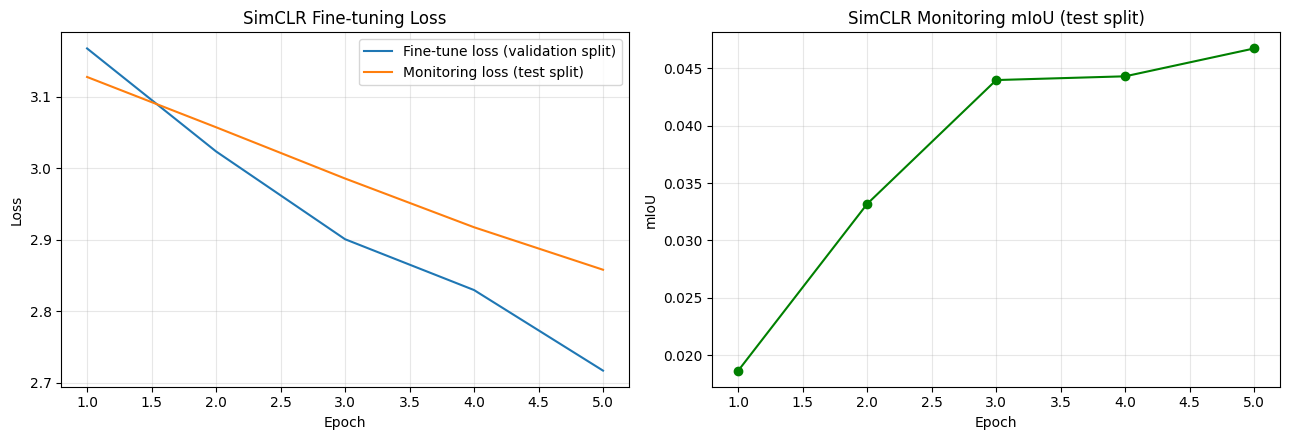

In [46]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, train_losses, label="Fine-tune loss (validation split)")
axes[0].plot(epochs_range, valid_losses_monitor, label="Monitoring loss (test split)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{CONFIG['method']} Fine-tuning Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, monitor_mious, marker="o", color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mIoU")
axes[1].set_title(f"{CONFIG['method']} Monitoring mIoU (test split)"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_finetune_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Save summary for Task E / Final Comparison notebook

In [47]:
finetune_summary = {
    "method": CONFIG["method"],
    "freeze_encoder": CONFIG["freeze_encoder"],
    "finetune_epochs": FT_CONFIG["finetune_epochs"],
    "final_epoch_50_mIoU": monitor_mious[-1],
    "best_monitor_mIoU": best_miou,
    "finetune_time_minutes": finetune_time / 60,
    "labelled_images_used": len(valid_df),
    "best_checkpoint_path": best_ckpt_path,
}

with open(f"/kaggle/working/{CONFIG['method'].lower()}_finetune_summary.json", "w") as f:
    json.dump(finetune_summary, f, indent=2)

print(json.dumps(finetune_summary, indent=2))
print("\nNext: Task E loads best_ckpt_path, evaluates on test_loader one final time for reported metrics,")
print("then Task F does error analysis on the worst-performing test images.")


{
  "method": "SimCLR",
  "freeze_encoder": true,
  "finetune_epochs": 5,
  "final_epoch_50_mIoU": 0.046732193483351406,
  "best_monitor_mIoU": 0.046732193483351406,
  "finetune_time_minutes": 2.2147074858347575,
  "labelled_images_used": 60,
  "best_checkpoint_path": "/kaggle/working/simclr_best_finetuned.pth"
}

Next: Task E loads best_ckpt_path, evaluates on test_loader one final time for reported metrics,
then Task F does error analysis on the worst-performing test images.


---
# Task E — Testing, Metrics & Label-Efficiency Comparison

Load the BEST checkpoint saved in Task D (selected by monitoring mIoU) and
run ONE final pass over the test split to report the metrics that go in the
report and the Final Comparison notebook. This reuses the same test_loader
from Task D — per Section 2's caveat, the test split is deliberately used
both to monitor (Task D) and to report final numbers (here).

In [48]:
best_checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}, "
      f"monitor mIoU at save time: {best_checkpoint['monitor_miou']:.4f}")


Loaded best checkpoint from epoch 5, monitor mIoU at save time: 0.0467


## Full confusion matrix + per-image IoU tracking

Accumulate the confusion matrix across the whole test set (needed for
per-class IoU / Dice), and keep a per-image mIoU list (needed for Task F's
worst-image visualization).

In [49]:
def update_confusion_matrix(conf_mat, preds, masks, num_classes):
    preds = preds.reshape(-1); masks = masks.reshape(-1)
    valid = (masks >= 0) & (masks < num_classes)
    idx = num_classes * masks[valid] + preds[valid]
    conf_mat += torch.bincount(idx, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return conf_mat


num_classes = CONFIG["num_classes"]
confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.long)

per_image_records = []   # (image_path, mask_path, per-image mIoU) for Task F

all_test_paths = test_df[["image_path", "mask_path"]].reset_index(drop=True)
running_idx = 0

with torch.no_grad():
    for images, masks in test_loader:
        images_gpu, masks_gpu = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images_gpu)
        preds = torch.argmax(logits, dim=1)

        confusion_matrix = update_confusion_matrix(confusion_matrix, preds.cpu(), masks_gpu.cpu(), num_classes)

        for i in range(images.shape[0]):
            img_iou = mean_iou(preds[i].cpu(), masks_gpu[i].cpu(), num_classes)
            row = all_test_paths.iloc[running_idx]
            per_image_records.append({
                "image_path": row["image_path"],
                "mask_path": row["mask_path"],
                "iou": img_iou,
            })
            running_idx += 1

print(f"Evaluated {running_idx} test images.")


Evaluated 60 test images.


## Compute final metrics from the confusion matrix

In [50]:
def metrics_from_confusion(conf_mat):
    conf_mat = conf_mat.float()
    tp = torch.diag(conf_mat)
    fp = conf_mat.sum(dim=0) - tp
    fn = conf_mat.sum(dim=1) - tp

    union = tp + fp + fn
    per_class_iou_final = torch.where(union > 0, tp / union, torch.tensor(float("nan")))
    per_class_dice = torch.where((2*tp+fp+fn) > 0, 2*tp / (2*tp + fp + fn), torch.tensor(float("nan")))

    pixel_acc = tp.sum() / conf_mat.sum()
    return per_class_iou_final, per_class_dice, pixel_acc


final_per_class_iou, final_per_class_dice, final_pixel_acc = metrics_from_confusion(confusion_matrix)
final_miou = float(np.nanmean(final_per_class_iou.numpy()))
final_dice = float(np.nanmean(final_per_class_dice.numpy()))

print(f"=== {CONFIG['method']} — Final Test-Set Metrics ===")
print(f"mIoU:          {final_miou:.4f}")
print(f"Mean Dice:     {final_dice:.4f}")
print(f"Pixel Accuracy:{final_pixel_acc:.4f}")
print(f"\nPer-class IoU:")
for c in range(num_classes):
    val = final_per_class_iou[c].item()
    print(f"  Class {c}: {val:.4f}" if not np.isnan(val) else f"  Class {c}: (not present in test set)")


=== SimCLR — Final Test-Set Metrics ===
mIoU:          0.0559
Mean Dice:     0.0940
Pixel Accuracy:0.1756

Per-class IoU:
  Class 0: 0.0140
  Class 1: 0.0006
  Class 2: 0.0245
  Class 3: 0.3847
  Class 4: 0.0394
  Class 5: 0.0590
  Class 6: 0.0000
  Class 7: 0.1085
  Class 8: 0.0264
  Class 9: 0.2880
  Class 10: 0.0197
  Class 11: 0.0259
  Class 12: 0.0000
  Class 13: 0.0104
  Class 14: 0.0004
  Class 15: 0.0358
  Class 16: 0.0000
  Class 17: 0.0389
  Class 18: 0.0132
  Class 19: 0.0853
  Class 20: 0.0770
  Class 21: 0.0331
  Class 22: 0.0013
  Class 23: (not present in test set)


## Confusion matrix heatmap (required plot)

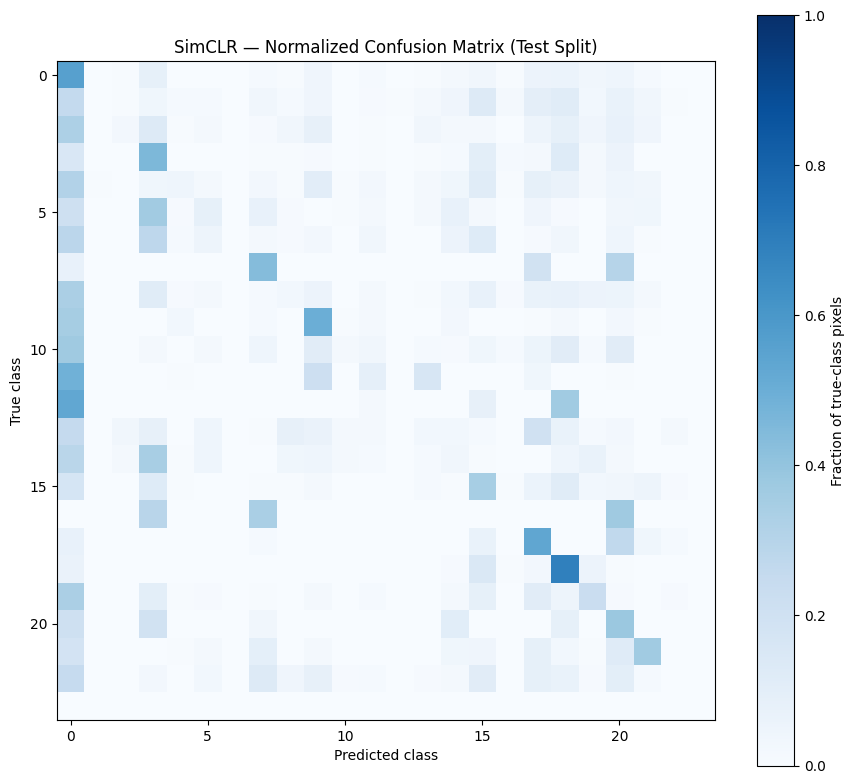

In [51]:
plt.figure(figsize=(9, 8))
cm_normalized = confusion_matrix.float() / (confusion_matrix.sum(dim=1, keepdim=True) + 1e-8)
plt.imshow(cm_normalized.numpy(), cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="Fraction of true-class pixels")
plt.xlabel("Predicted class"); plt.ylabel("True class")
plt.title(f"{CONFIG['method']} — Normalized Confusion Matrix (Test Split)")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## Save Task E results — this is what the Final Comparison notebook reads

In [52]:
results = {
    "method": CONFIG["method"],
    "freeze_encoder": CONFIG["freeze_encoder"],
    "num_test_images": len(test_df),
    "num_labelled_finetune_images": len(valid_df),
    "test_mIoU": final_miou,
    "test_mean_dice": final_dice,
    "test_pixel_accuracy": float(final_pixel_acc),
    "per_class_iou": [None if np.isnan(v) else float(v) for v in final_per_class_iou.numpy()],
    "best_checkpoint_epoch": best_checkpoint["epoch"],
}

with open(f"/kaggle/working/{CONFIG['method'].lower()}_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))


{
  "method": "SimCLR",
  "freeze_encoder": true,
  "num_test_images": 60,
  "num_labelled_finetune_images": 60,
  "test_mIoU": 0.055915769189596176,
  "test_mean_dice": 0.09396889060735703,
  "test_pixel_accuracy": 0.17563077807426453,
  "per_class_iou": [
    0.014047629199922085,
    0.000561860273592174,
    0.024461684748530388,
    0.3847357928752899,
    0.039443548768758774,
    0.05898313969373703,
    0.0,
    0.10851754248142242,
    0.026381760835647583,
    0.28797370195388794,
    0.01969359815120697,
    0.025859415531158447,
    0.0,
    0.010382234118878841,
    0.0004422344791237265,
    0.03575306385755539,
    0.0,
    0.03885935992002487,
    0.013244404457509518,
    0.0853034108877182,
    0.07701708376407623,
    0.03312641754746437,
    0.0012748076114803553,
    null
  ],
  "best_checkpoint_epoch": 5
}


---
# Task F — Error Analysis

Visualize the worst-performing test images (lowest per-image IoU) against
ground truth, and discuss whether errors concentrate on particular
classes/regions.

In [53]:
per_image_df = pd.DataFrame(per_image_records).sort_values("iou")
worst_n = per_image_df.head(6)

print("Worst-performing test images (lowest IoU):")
print(worst_n[["image_path", "iou"]].to_string(index=False))


Worst-performing test images (lowest IoU):
                                                                                                      image_path      iou
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/170.jpg 0.000238
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/013.jpg 0.000844
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/593.jpg 0.000905
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/101.jpg 0.001253
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/110.jpg 0.002839
/kaggle/input/datasets/bulentsiyah/semantic-drone-dataset/dataset/semantic_drone_dataset/original_images/305.jpg 0.002921


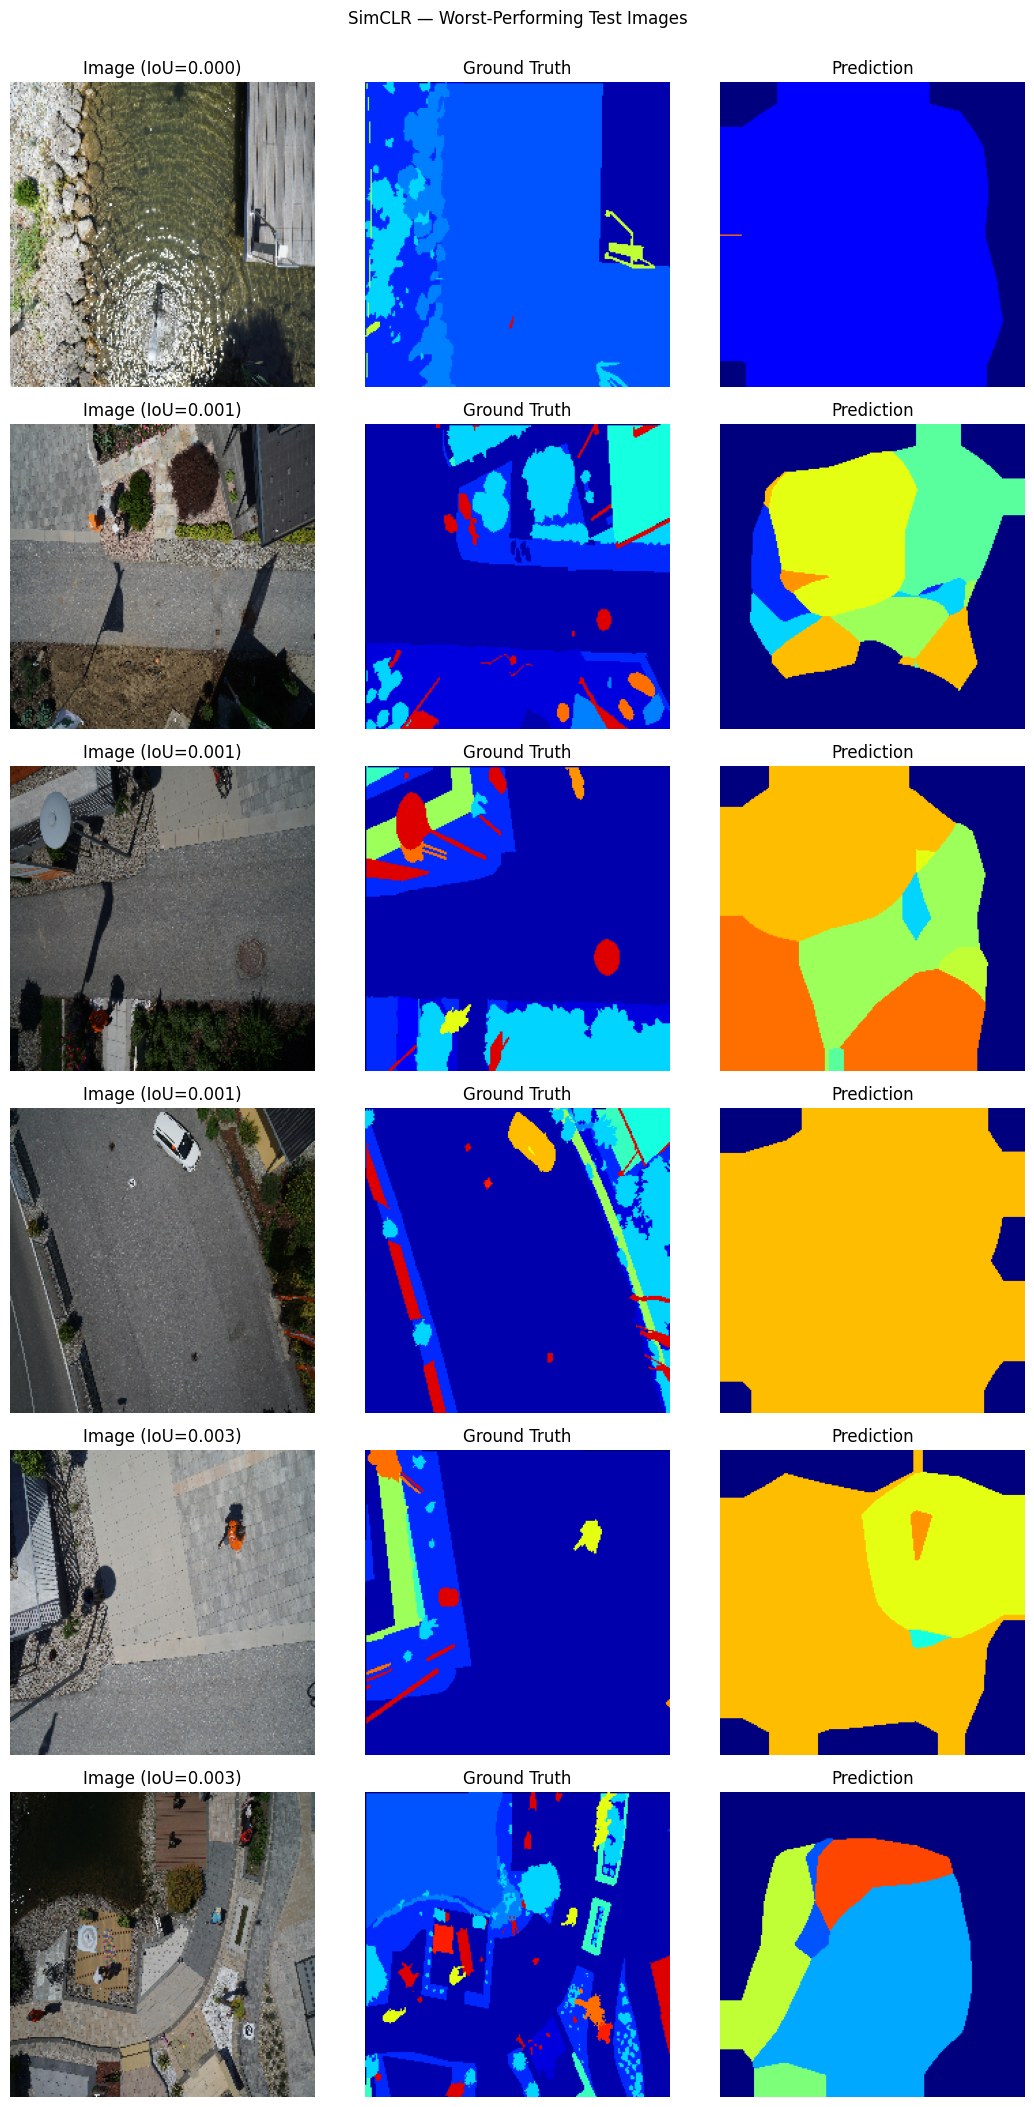

In [54]:
def load_and_predict(image_path, mask_path, model, transform, device):
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    out = transform(image=image, mask=mask)
    img_tensor, gt_mask = out["image"], out["mask"]

    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu()

    def denorm(t):
        mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
        return np.clip(t.numpy() * std + mean, 0, 1).transpose(1, 2, 0)

    return denorm(img_tensor), gt_mask.numpy(), pred_mask.numpy()


fig, axes = plt.subplots(len(worst_n), 3, figsize=(11, 3.5 * len(worst_n)))

for row_idx, (_, row) in enumerate(worst_n.iterrows()):
    img, gt, pred = load_and_predict(row["image_path"], row["mask_path"], model, eval_transform, DEVICE)

    axes[row_idx, 0].imshow(img); axes[row_idx, 0].set_title(f"Image (IoU={row['iou']:.3f})"); axes[row_idx, 0].axis("off")
    axes[row_idx, 1].imshow(gt, cmap="jet", vmin=0, vmax=num_classes); axes[row_idx, 1].set_title("Ground Truth"); axes[row_idx, 1].axis("off")
    axes[row_idx, 2].imshow(pred, cmap="jet", vmin=0, vmax=num_classes); axes[row_idx, 2].set_title("Prediction"); axes[row_idx, 2].axis("off")

plt.suptitle(f"{CONFIG['method']} — Worst-Performing Test Images", y=1.001)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## Which classes dominate the errors on these worst images?

Compare against your Part-A error analysis (Task F asks: same classes/images,
or different? hypothesize why in the report's Section 6.7/6.9).

In [55]:
error_class_counts = Counter()
for _, row in worst_n.iterrows():
    _, gt, pred = load_and_predict(row["image_path"], row["mask_path"], model, eval_transform, DEVICE)
    wrong_pixels_mask = (gt != pred)
    wrong_true_classes = gt[wrong_pixels_mask]
    for c in np.unique(wrong_true_classes):
        error_class_counts[int(c)] += int((wrong_true_classes == c).sum())

print(f"{CONFIG['method']} — pixel error counts by TRUE class, across worst-{len(worst_n)} images:")
for cls, count in sorted(error_class_counts.items(), key=lambda x: -x[1]):
    print(f"  Class {cls}: {count} misclassified pixels")

print("\nUse this to discuss in Section 6.7: does this method's error concentrate on the")
print("same classes as Part A's supervised baseline, or different ones? Why might that be")
print("(e.g. SSL encoders transferring texture/shape priors differently than a purely")
print("supervised backbone)?")


SimCLR — pixel error counts by TRUE class, across worst-6 images:
  Class 1: 164923 misclassified pixels
  Class 5: 37649 misclassified pixels
  Class 4: 31875 misclassified pixels
  Class 8: 22338 misclassified pixels
  Class 2: 13335 misclassified pixels
  Class 22: 7255 misclassified pixels
  Class 6: 5459 misclassified pixels
  Class 13: 4588 misclassified pixels
  Class 9: 4310 misclassified pixels
  Class 10: 2057 misclassified pixels
  Class 19: 1409 misclassified pixels
  Class 15: 896 misclassified pixels
  Class 3: 785 misclassified pixels
  Class 0: 751 misclassified pixels
  Class 14: 472 misclassified pixels
  Class 21: 426 misclassified pixels
  Class 18: 193 misclassified pixels

Use this to discuss in Section 6.7: does this method's error concentrate on the
same classes as Part A's supervised baseline, or different ones? Why might that be
(e.g. SSL encoders transferring texture/shape priors differently than a purely
supervised backbone)?


---
# Representation Diagnostics — Pair Similarity & t-SNE

Directly supports the viva point: **"a lower SSL loss alone does not prove
better segmentation; downstream metrics must confirm transfer quality."**
Task E already gave the downstream proof (mIoU/Dice). This section gives the
representation-level evidence *underneath* that number — does the encoder's
embedding space actually organize images sensibly, and did the pretext task
actually pull augmented views of the same image together?

Both diagnostics reuse `model.encoder` directly (before the decoder/adapter),
so this reflects exactly what Task C attached — not a separate side-model.

In [56]:
from sklearn.manifold import TSNE
import torchvision.transforms as T
from PIL import Image

def get_pooled_embedding(model, x):
    """Global-average-pool the encoder's feature map -> a single vector per image.
    Works identically for CNN (SimCLR/BYOL) and ViT (MAE/DINOv2) encoders here,
    since Task C already unified their output to [B, C, H, W]."""
    with torch.no_grad():
        feat = model.encoder(x)          # [B, C, H, W]
        emb = feat.mean(dim=[2, 3])        # [B, C]
    return emb


## t-SNE of encoder embeddings, colored by ground-truth majority class

If the SSL pretext task learned something meaningful, images dominated by
the same class should cluster together in this 2D projection — even though
the encoder never saw a single label during Task B pretraining.

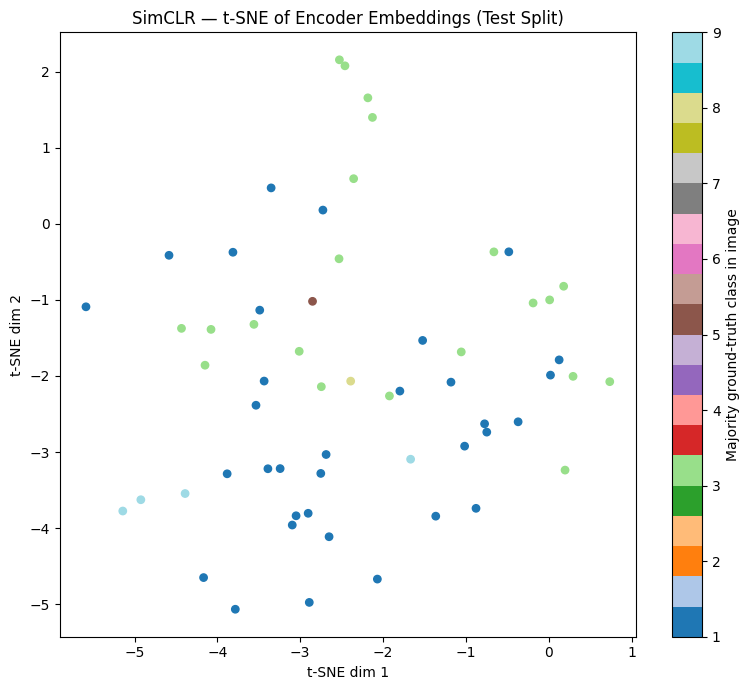

In [57]:
N_TSNE_SAMPLES = min(200, len(test_df))
tsne_sample_df = test_df.sample(N_TSNE_SAMPLES, random_state=42).reset_index(drop=True)

embeddings, majority_classes = [], []
model.eval()

for _, row in tsne_sample_df.iterrows():
    image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    out = eval_transform(image=image, mask=mask)
    img_tensor = out["image"].unsqueeze(0).to(DEVICE)

    emb = get_pooled_embedding(model, img_tensor)
    embeddings.append(emb.cpu().numpy().squeeze())

    vals, counts = np.unique(out["mask"].numpy(), return_counts=True)
    majority_classes.append(int(vals[np.argmax(counts)]))   # dominant class in this image's mask

embeddings = np.stack(embeddings)
majority_classes = np.array(majority_classes)

tsne = TSNE(n_components=2, perplexity=min(30, N_TSNE_SAMPLES - 1), random_state=42, init="pca")
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=majority_classes, cmap="tab20", s=28)
plt.colorbar(scatter, label="Majority ground-truth class in image")
plt.title(f"{CONFIG['method']} — t-SNE of Encoder Embeddings (Test Split)")
plt.xlabel("t-SNE dim 1"); plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_tsne.png", dpi=150, bbox_inches="tight")
plt.show()


## Pair-similarity check — did the pretext task actually work?

Take real test images, generate two augmented views of each (same style of
augmentation as Task B), and compare:
- **Positive pairs**: two views of the SAME image
- **Negative pairs**: views of DIFFERENT images (shuffled)

A well-trained SSL encoder should show clearly higher cosine similarity for
positive pairs than negative pairs. If the two distributions overlap
heavily, the pretext task didn't strongly separate "same image" from
"different image" in embedding space — useful to know even if downstream
mIoU still looks reasonable.

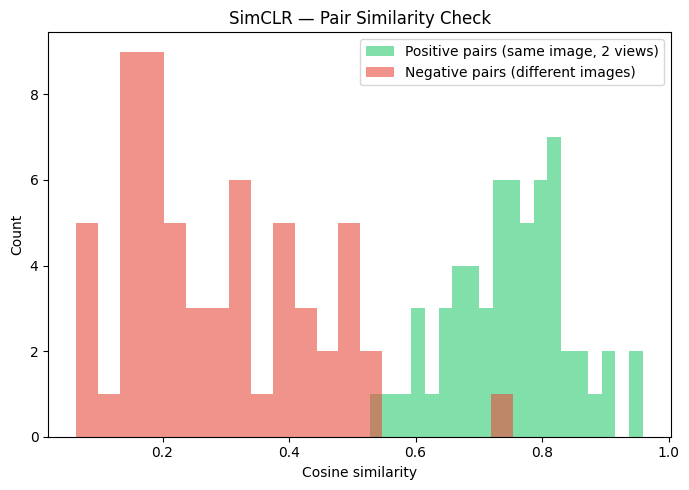

Mean positive-pair similarity: 0.7496
Mean negative-pair similarity: 0.2823
Gap: 0.4673

A clear positive-vs-negative gap here is representation-level evidence
that the pretext task worked -- independent of, and complementary to,
the downstream mIoU/Dice numbers already reported in Task E.


In [58]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

pair_transform = T.Compose([
    T.RandomResizedCrop(CONFIG["image_size"], scale=(0.4, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

N_PAIR_SAMPLES = min(64, len(test_df))
pair_sample_df = test_df.sample(N_PAIR_SAMPLES, random_state=42).reset_index(drop=True)

view1_embs, view2_embs = [], []
for _, row in pair_sample_df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    v1 = pair_transform(img).unsqueeze(0).to(DEVICE)
    v2 = pair_transform(img).unsqueeze(0).to(DEVICE)
    view1_embs.append(get_pooled_embedding(model, v1).cpu().numpy().squeeze())
    view2_embs.append(get_pooled_embedding(model, v2).cpu().numpy().squeeze())

view1_embs = np.stack(view1_embs)
view2_embs = np.stack(view2_embs)

def cosine_sim(a, b):
    return np.sum(a * b, axis=-1) / (np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1) + 1e-8)

positive_sims = cosine_sim(view1_embs, view2_embs)

rng = np.random.default_rng(42)
shuffled_view2 = view2_embs[rng.permutation(len(view2_embs))]
negative_sims = cosine_sim(view1_embs, shuffled_view2)

plt.figure(figsize=(7, 5))
plt.hist(positive_sims, bins=20, alpha=0.6, label="Positive pairs (same image, 2 views)", color="#2ecc71")
plt.hist(negative_sims, bins=20, alpha=0.6, label="Negative pairs (different images)", color="#e74c3c")
plt.xlabel("Cosine similarity"); plt.ylabel("Count")
plt.title(f"{CONFIG['method']} — Pair Similarity Check")
plt.legend()
plt.tight_layout()
plt.savefig(f"/kaggle/working/{CONFIG['method'].lower()}_pair_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean positive-pair similarity: {positive_sims.mean():.4f}")
print(f"Mean negative-pair similarity: {negative_sims.mean():.4f}")
print(f"Gap: {positive_sims.mean() - negative_sims.mean():.4f}")
print("\nA clear positive-vs-negative gap here is representation-level evidence")
print("that the pretext task worked -- independent of, and complementary to,")
print("the downstream mIoU/Dice numbers already reported in Task E.")


## Save diagnostic summary

In [59]:
diagnostic_summary = {
    "method": CONFIG["method"],
    "mean_positive_pair_similarity": float(positive_sims.mean()),
    "mean_negative_pair_similarity": float(negative_sims.mean()),
    "similarity_gap": float(positive_sims.mean() - negative_sims.mean()),
    "tsne_samples": N_TSNE_SAMPLES,
    "pair_samples": N_PAIR_SAMPLES,
}

with open(f"/kaggle/working/{CONFIG['method'].lower()}_diagnostics.json", "w") as f:
    json.dump(diagnostic_summary, f, indent=2)

print(json.dumps(diagnostic_summary, indent=2))


{
  "method": "SimCLR",
  "mean_positive_pair_similarity": 0.7495874166488647,
  "mean_negative_pair_similarity": 0.28225332498550415,
  "similarity_gap": 0.4673340916633606,
  "tsne_samples": 60,
  "pair_samples": 60
}
